In [ ]:
from MEA1D.MEA1D_conf import *

In [29]:
class AGDL:
    def __init__(self):
        self.U = 1.15
    def dydx(self, x, y):
        phi_e, j_e, phi_p, j_p, T, j_T, lambda_, j_lambda, x_H2O, j_H2O, x_H2, j_H2, x_O2, j_O2, s, j_s = [y[i_var, :]for i_var in range(16)]
        dphi_e, dj_e, dphi_p, dj_p, dT, dj_T, dlambda, dj_lambda, dx_H2O, dj_H2O, dx_H2, dj_H2, dx_O2, dj_O2, ds, dj_s = [np.zeros(y.shape[1]) for _ in range(16)]
        
        # AGDL
        C = P_A / (R * T[:11])  # total interstitial gas concentration
        dphi_e[:11] = -j_e[:11] / sigma_e_GDL  # electron flux: j_e = -sigma_e*grad(phi_e)
        dT[:11] = -j_T[:11] / k_GDL  # heat flux: j_T = -k*grad(T)
        dj_T[:11] = -j_e[:11] * dphi_e[:11]  # conservation of heat: div(j_T) = S_T
        dx_H2O[:11] = -j_H2O[:11] / (C * D_H2O_A(eps_p_GDL, tau_GDL, s[:11], T[:11]))  # water vapor flux: j_H2O = -C*D_H2O*grad(x_H2O)
        dx_H2[:11] = -j_H2[:11] / (C * D_H2(eps_p_GDL, tau_GDL, s[:11], T[:11]))  # hydrogen flux: j_H2 = -C*D_H2*grad(x_H2)
        
        return [dphi_e, dj_e,
                dphi_p, dj_p,
                dT, dj_T,
                dlambda, dj_lambda,
                dx_H2O, dj_H2O,
                dx_H2, dj_H2,
                dx_O2, dj_O2,
                ds, dj_s]
    
    def y_init(self, x):
        T = (T_C + T_A) / 2
        x_H2O = x_H2O_A
        x_H2 = x_H2_A
        return np.array([0, 0, 0, 0, T, 0, 0, 0, x_H2O, 0, x_H2, 0, 0, 0, 0, 0])
    
    def bcfun(self,ya, yb):
        
        res = np.zeros(len(ya))

        # ELECTRONS
        res[0] = ya[0]
        res[1] = yb[0] - self.U

        # PROTONS
        res[2] = ya[2]
        res[3] = yb[2]

        # TEMPERATURE
        res[4] = ya[4] - T_A
        res[5] = yb[4] - T_C

        # DISSOLVED WATER
        res[6] = ya[6]
        res[7] = yb[6]

        # WATER VAPOR
        res[8] = ya[8] - x_H2O_A
        res[9] = yb[8] - x_H2O_C

        # HYDROGEN
        res[10] = ya[10] - x_H2_A
        res[11] = yb[10] 

        # OXYGEN
        res[12] = ya[12]
        res[13] = yb[12] - x_O2_C

        # LIQUID WATER
        res[14] = ya[15]
        res[15] = yb[14] - s_C

        return np.array(res)

   Iteration    Max residual  Max BC residual  Total nodes    Nodes added  
Singular Jacobian encountered when solving the collocation system on iteration 1. 
Maximum relative residual: 0.00e+00 
Maximum boundary residual: 0.00e+00
   Iteration    Max residual  Max BC residual  Total nodes    Nodes added  
Singular Jacobian encountered when solving the collocation system on iteration 1. 
Maximum relative residual: 0.00e+00 
Maximum boundary residual: 0.00e+00
   Iteration    Max residual  Max BC residual  Total nodes    Nodes added  
Singular Jacobian encountered when solving the collocation system on iteration 1. 
Maximum relative residual: 0.00e+00 
Maximum boundary residual: 0.00e+00
   Iteration    Max residual  Max BC residual  Total nodes    Nodes added  
Singular Jacobian encountered when solving the collocation system on iteration 1. 
Maximum relative residual: 0.00e+00 
Maximum boundary residual: 0.00e+00
   Iteration    Max residual  Max BC residual  Total nodes    Nodes adde

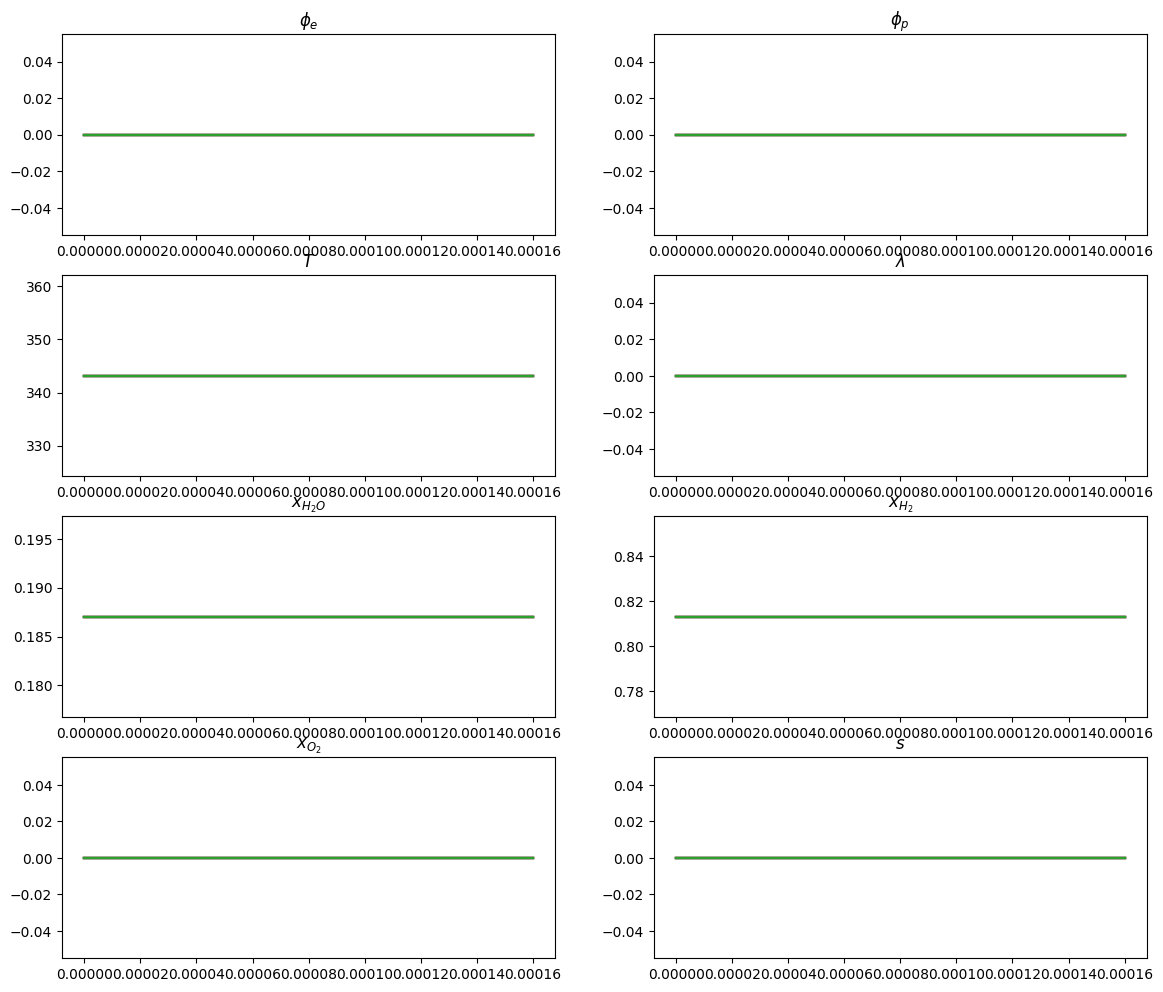

In [30]:
solutions = []

for Ustack in U:
    model = AGDL()
    model.U = Ustack
    x_init = np.linspace(0,1.60e-4,11)
    y0 = np.zeros((16, len(x_init)))
    for i in range(11):
        y0[:, i] = model.y_init(x_init)

    sol = solve_bvp(fun=model.dydx,bc = model.bcfun,x=x_init,y=y0,verbose=2)
    solutions.append(sol)

fig, ax = plt.subplots(nrows=4,ncols=2,figsize=(14,12))
titles = [r'$\phi_e$',r'$\phi_p$',r'$T$',r'$\lambda$',r'$x_{H_2O}$',r'$x_{H_2}$',r'$x_{O_2}$',r'$s$']
i_sol = 0
for sol in solutions:
    for i_var in range(8):
        ax[i_var//2,i_var%2].plot(x_init,sol.y[i_var*2,:55],label = f"U = {U[i_sol]:.2f}")
        ax[i_var//2,i_var%2].set_title(titles[i_var])
    i_sol += 1